# Lesson 02 · Empirical Bayes estimation

**Source:** *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapter 3 (pp. 20–27)

**Question:** Which is better, 4 hits in 10 at-bats or 300 in 1,000? Who were the best and worst hitters in history, when some players batted once and others ten thousand times?

**Goal:** Estimate a beta prior from the whole dataset by maximum likelihood, then shrink each player's average toward it.

**Contents**

1. Build the career batting table
2. Why raw averages fail
3. Step 1: estimate a prior from all the data
4. Step 2: shrink each player toward the prior
5. Results: the best and worst batters
6. Seeing shrinkage
7. Save your prior for later lessons
8. Exercises

**Tags:** `empirical-bayes` `beta-binomial` `maximum-likelihood` `shrinkage` `scipy-optimize` `pandas-joins`

**Before you start:** Lesson 01. The first run downloads about 10 MB of data into `data/lahman/`.

*How this notebook works:* each **Your turn** prompt is followed by an empty cell for your code. **Check** boxes give values to compare against; they come from the book, and your numbers can differ slightly because the Lahman data now runs through more recent seasons. **Reflect** prompts are for short written answers. Every prompt is numbered *lesson.section.question* (for example **2.3.1**), so you can refer to it; empty code cells and answer cells carry the same number.

In [1]:
# --- Setup: run this cell first ------------------------------------------
# Windows + conda: put the environment's DLL folders on PATH, so plotting
# can't crash the kernel when Jupyter wasn't started from the activated env.
import os, sys
for sub in ["Library\\mingw-w64\\bin", "Library\\usr\\bin", "Library\\bin", "Scripts", "bin"]:
    p = os.path.join(sys.prefix, sub)
    if os.path.isdir(p) and p not in os.environ["PATH"]:
        os.environ["PATH"] = p + os.pathsep + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats, optimize, special

import eb_data   # helpers in this folder: loading the Lahman data, saving results

rng = np.random.default_rng(2017)
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (7, 4)
print(f"numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__}")

# Download the Lahman tables the first time (skips files you already have)
eb_data.download_lahman()
batting = eb_data.load_table("Batting")
pitching = eb_data.load_table("Pitching")
people = eb_data.load_table("People")
print(f"Batting: {len(batting):,} rows | Pitching: {len(pitching):,} | People: {len(people):,}")

numpy 2.5.3 | pandas 3.0.6 | scipy 1.18.1
Lahman data folder: C:\Users\XPS-13\Dropbox\Programming\BayesStatsCardsandComputers\empirical_bayes\data\lahman
[1/3] Batting.csv already here (8.0 MB), skipping
[2/3] Pitching.csv already here (5.1 MB), skipping
[3/3] People.csv already here (3.2 MB), skipping
Done: 3 of 3 tables ready.
Batting: 128,598 rows | Pitching: 57,630 | People: 24,270


## 1. Build the career batting table

Each row of `Batting` is one player's season with one team (a *stint*). We want one row per player, with career hits `H` and at-bats `AB`. In this chapter the book drops **anyone who ever pitched**, because pitchers are much weaker hitters and form a different population. (We'll come back to them in Lesson 08.)

**2.1.1 · Your turn.** Build `career` with columns `playerID, name, H, AB, average`:
1. keep rows with `AB > 0`;
2. drop every `playerID` that appears in `pitching` (an *anti-join*: `~batting["playerID"].isin(...)`);
3. group by player and sum `H` and `AB`;
4. add `average = H / AB`;
5. merge in names from `people` (`nameFirst + " " + nameLast`).

In [2]:
# 2.1.1 · Your code here
career = batting[~batting["playerID"].isin(pitching["playerID"])]
career = career[career["AB"] > 0]
career = career.groupby('playerID', as_index=False).agg({'H': 'sum', 'AB': 'sum'})
career['average'] = career['H']/career['AB']

names = people[["playerID", "nameFirst", "nameLast"]].copy()
names["name"] = names["nameFirst"] + " " + names["nameLast"]

career = pd.merge(names[['playerID', 'name']], career, on='playerID')
career.head()

,playerID,name,H,AB,average
0,aaronha01,Hank Aaron,3771,12364,0.3050
1,aaronto01,Tommie Aaron,216,944,0.2288
2,abadan01,Andy Abad,2,21,0.0952
3,abadijo01,John Abadie,11,49,0.2245
4,abbated01,Ed Abbaticchio,772,3044,0.2536


**2.1.2 · Your turn.** Compare your table with `eb_data.career(pitcher_rule=None)`, which follows the same recipe. Do the row counts and totals match?

In [3]:
# 2.1.2 · Your code
eb_data.career(pitcher_rule=None).shape, career.shape

((11725, 5), (11725, 5))

> **Check:** the book had 9,342 players. Expect a few hundred more with recent seasons.

## 2. Why raw averages fail

**2.2.1 · Your turn.** Show the 5 players with the highest raw average and the 5 with the lowest. Include `H` and `AB`.

In [4]:
# 2.2.1 · Your code here
career = career.sort_values('average', ascending = False)
print(pd.concat([career.head(), career.tail()]))

        playerID           name  H  AB  average
360    averysk01     Skip Avery  1   1      1.0
10695     tuck01            NaN  1   1      1.0
10705  tupmama01    Matt Tupman  1   1      1.0
844    birasst01    Steve Biras  2   2      1.0
4871   hopkimi01   Mike Hopkins  2   2      1.0
5089     jacks05            NaN  0   3      0.0
5088     jacks04            NaN  0   1      0.0
5087     jacks03            NaN  0   5      0.0
8459   pratses01  Esteban Prats  0   3      0.0
9828   smithhe03  Herbert Smith  0   2      0.0


**2.2.2 · Reflect.** What do the top and bottom lists have in common? One common fix is a minimum-AB filter. What's wrong with that fix?

*2.2.2 · Your answer:*

Both lists have low AB values- players with few observations with which to draw meaningful conclusions. A minimum AB filter does assist with that, but the decision would be essentially arbitrary at this time. What is a meaningful minimum AB? It could throw away valuable data if we set it too high, and non-contributory players with low ABs could persist in the data if we set it too low.

## 3. Step 1: estimate a prior from all the data

We model each player's true average as a draw from one beta distribution, and his hits as binomial given that average:

$$p_i \sim \text{Beta}(\alpha_0, \beta_0), \qquad H_i \sim \text{Binomial}(AB_i, p_i).$$

Averaging over the unknown $p_i$ gives the **beta-binomial** distribution for $H_i$. We choose the *hyperparameters* $\alpha_0, \beta_0$ that maximize the beta-binomial likelihood of the observed hits. In SciPy that's `stats.betabinom.logpmf(H, AB, a, b)`.

Following the book, fit the prior only on players with **more than 500 at-bats**, where the averages are less noisy. (Lesson 06 shows why this filter is a crude fix.)

**2.3.1 · Your turn.** Plot a histogram of `average` for players with `AB > 500`. Does a single-peaked beta look plausible?

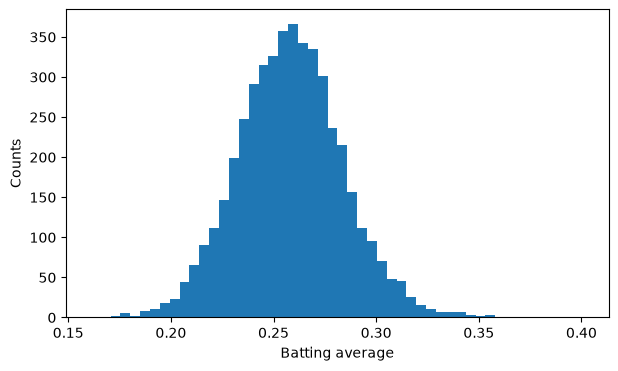

Certainly looks reasonable.

In [5]:
# 2.3.1 · Your code here
from IPython.display import display, Markdown
career500 = career[career['AB'] > 500]

plt.hist(career500.average, bins = 50)
plt.xlabel('Batting average')
plt.ylabel('Counts')
plt.show()

display(Markdown('Certainly looks reasonable.'))

**2.3.2 · Your turn.** Write `neg_log_lik(params, H, AB)` returning the negative summed beta-binomial log-likelihood, then minimize it with `optimize.minimize`.

Tip: optimize over `log(alpha), log(beta)` so the parameters stay positive without bounds. Start from something like `alpha = 1, beta = 10`.

In [6]:
# 2.3.2 · Your code here
def neg_log_lik(params, H, AB):
    log_a, log_b = params       
    a, b = np.exp(log_a), np.exp(log_b)
    bbsum = stats.betabinom.logpmf(H, AB, a, b).sum()
    return -bbsum             

res = optimize.minimize(neg_log_lik, x0=np.log([1, 10]), args=(career500.H, career500.AB), method="Nelder-Mead")
alpha0, beta0 = np.exp(res.x)
alpha0, beta0

(np.float64(95.33056816538446), np.float64(271.48639186080146))

> **Check:** α₀ ≈ 101.4 and β₀ ≈ 287.3, so the prior mean α₀/(α₀+β₀) ≈ 0.261.

**2.3.3 · Your turn.** Overlay the fitted Beta(α₀, β₀) density on the histogram (use `density=True`).

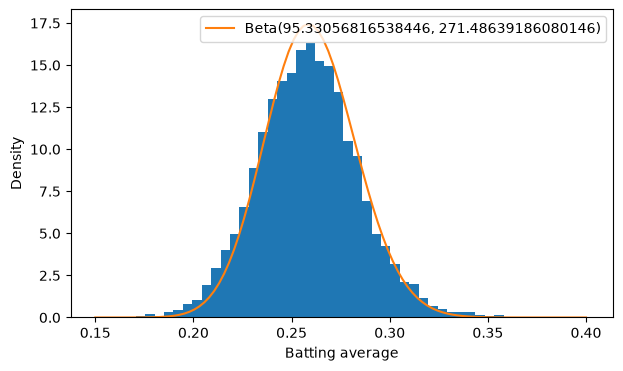

In [7]:
# 2.3.3 · Your code here
x = np.linspace(0.15, 0.4, 100)
plt.hist(career500.average, bins = 50, density = True)
plt.plot(x, stats.beta(alpha0, beta0).pdf(x), label = f"Beta({alpha0}, {beta0})")
plt.xlabel('Batting average')
plt.ylabel('Density')
plt.legend()
plt.show()


**2.3.4 · Your turn.** A quicker alternative is the method of moments: match the mean and variance of `average` (for AB > 500) to the beta formulas. Compute it and compare with your MLE. Why might they differ?

Method of moments alpha: 74.34389776076492, Method of moments beta: 213.43642403551266


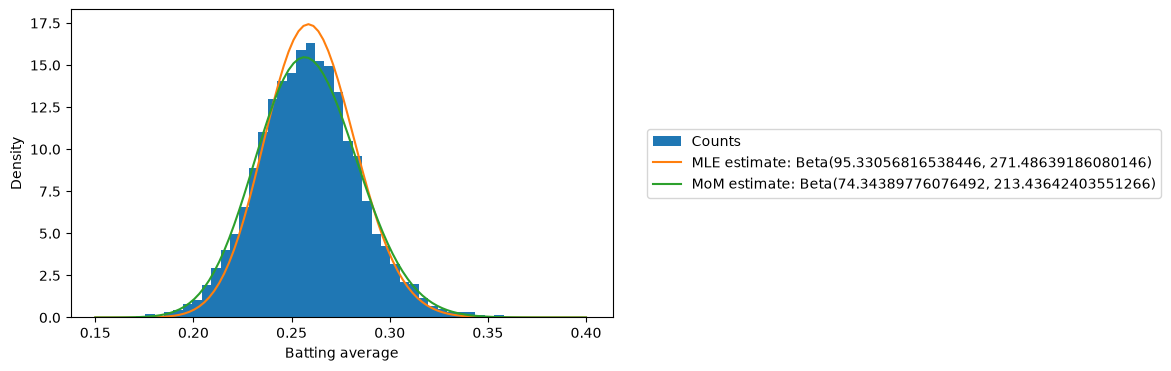

In [8]:
# 2.3.4 · Your code here
mom_mean = career500.average.mean()
mom_std = career500.average.std()

nu =(((mom_mean * (1-mom_mean)) / (mom_std **2)) - 1)
alpha_mom = mom_mean * nu
beta_mom = nu - alpha_mom
print(f"Method of moments alpha: {alpha_mom}, Method of moments beta: {beta_mom}")

plt.hist(career500.average, bins = 50, density = True, label = "Counts")
plt.plot(x, stats.beta(alpha0, beta0).pdf(x), label = f"MLE estimate: Beta({alpha0}, {beta0})")
plt.plot(x, stats.beta(alpha_mom, beta_mom).pdf(x), label = f"MoM estimate: Beta({alpha_mom}, {beta_mom})")
plt.xlabel('Batting average')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()

## 4. Step 2: shrink each player toward the prior

Now treat the fitted Beta($\alpha_0$, $\beta_0$) as everyone's prior, and update with each player's own record. The posterior mean is the **empirical Bayes estimate**:

$$\hat p_i = \frac{H_i + \alpha_0}{AB_i + \alpha_0 + \beta_0}.$$

**2.4.1 · Your turn.** Compute the estimate for a 300/1000 hitter and a 4/10 hitter.

In [9]:
# 2.4.1 · Your code here

post300 = ((300 + alpha0) / (1000 + alpha0 + beta0))
post4 = ((4 + alpha0) / (10 + alpha0 + beta0))
post300, post4

(np.float64(0.28923446205833636), np.float64(0.2636042925416142))

> **Check:** about 0.289 for 300/1000 and 0.264 for 4/10, so the 300/1000 hitter now ranks higher.

**2.4.2 · Your turn.** Add an `eb_estimate` column to `career` for every player.

In [10]:
# 2.4.2 · Your code here
career['eb_estimate'] = ((career.H + alpha0) / (career.AB + alpha0 + beta0))
career.head()

,playerID,name,H,AB,average,eb_estimate
360,averysk01,Skip Avery,1,1,1.0,0.2619
10695,tuck01,NaN,1,1,1.0,0.2619
10705,tupmama01,Matt Tupman,1,1,1.0,0.2619
844,birasst01,Steve Biras,2,2,1.0,0.2639
4871,hopkimi01,Mike Hopkins,2,2,1.0,0.2639


## 5. Results: the best and worst batters

**2.5.1 · Your turn.** Show the top 5 and bottom 5 players by `eb_estimate`, with `H`, `AB`, `average` and `eb_estimate`.

In [11]:
# 2.5.1 · Your code here
career = career.sort_values('eb_estimate', ascending = False)
print(pd.concat([career.head(), career.tail()]))

        playerID                  name     H    AB  average  eb_estimate
9800   smithch12         Charlie Smith   323   805   0.4012       0.3570
4883   hornsro01        Rogers Hornsby  2930  8173   0.3585       0.3543
5111   jacksjo01  Shoeless Joe Jackson  1772  4981   0.3558       0.3492
11443  wilsoju99            Jud Wilson  1351  3782   0.3572       0.3486
2618   delahed01          Ed Delahanty  2597  7510   0.3458       0.3418
418    bakerge01          George Baker    74   474   0.1561       0.2014
10926  vukovjo01         John Vukovich    90   559   0.1610       0.2002
3011   eastehe01       Henry Easterday   203  1129   0.1798       0.1994
7983   oylerra01             Ray Oyler   221  1265   0.1747       0.1939
751    bergebi01           Bill Bergen   516  3028   0.1704       0.1801


> **Check:** Rogers Hornsby should top the list (about .354). Bill Bergen should be near the bottom.

## 6. Seeing shrinkage

**2.6.1 · Your turn.** Scatter `average` (x) against `eb_estimate` (y), colored by `AB` on a log scale (`matplotlib.colors.LogNorm`). Add the line y = x and a horizontal line at the prior mean.

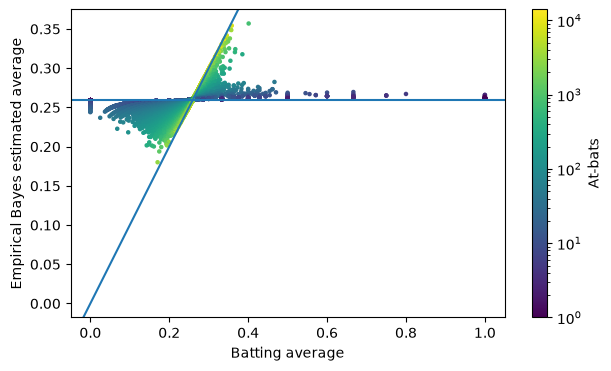

In [12]:
# 2.6.1 · Your code here
from matplotlib import colors
sc = plt.scatter(career.average, career.eb_estimate, c=career.AB, norm=colors.LogNorm(), cmap="viridis", s=5)
plt.axline((0, 0), slope=1)
plt.axhline(alpha0 / (alpha0 + beta0))
plt.colorbar(sc, label="At-bats")
plt.xlabel('Batting average')
plt.ylabel('Empirical Bayes estimated average')
plt.show()

**2.6.2 · Reflect.** Which points barely move, and which move a lot? Put the rule into one sentence.

*2.6.2 · Your answer:*
The players with more ABs move less, as their abundance of evidentiary at-bats far outweighs the prior and its estimated mean, and vice versa for players with fewer ABs

## 7. Save your prior for later lessons

Later lessons start from this prior. `eb_data.load_prior()` reads it back, and falls back to the book's values (101.4, 287.3) if you skip this step.

**2.7.1 · Your turn.** Save it: `eb_data.save_result("prior", {"alpha0": float(alpha0), "beta0": float(beta0)})`.

In [13]:
# 2.7.1 · Your code here
eb_data.save_result("prior", {"alpha0": float(alpha0), "beta0": float(beta0)})

Saved 'prior' to results.json


## 8. Exercises

**2.8.1 · Your turn.** How sensitive is the prior to the 500-AB cutoff? Refit with cutoffs of 100, 250, 1000 and 2000, and tabulate α₀, β₀ and the prior mean. What pattern do you see, and why might it happen? (Lesson 06 explains it.)

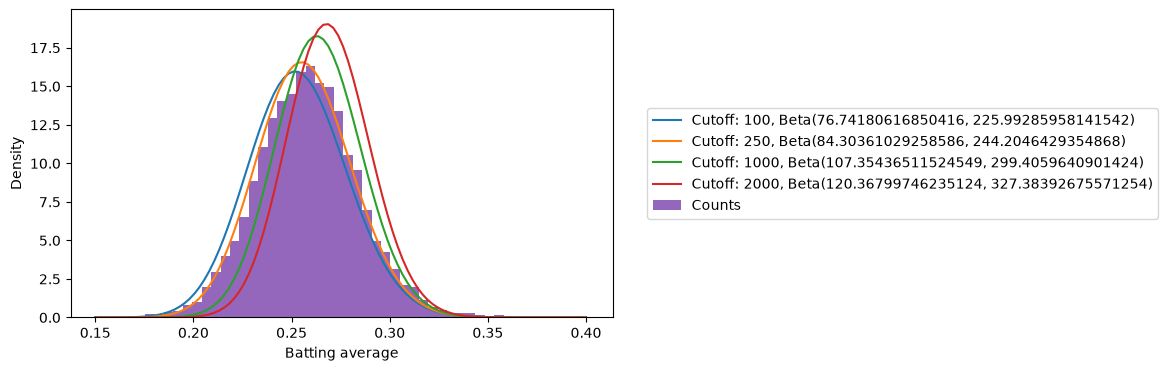

In [57]:
# 2.8.1 · Your code here

cutoffs = [100, 250, 1000, 2000]
x = np.linspace(0.15, 0.4, 100)
rows = []

for cutoff in cutoffs:
    players = career[career['AB'] > cutoff]
    res = optimize.minimize(neg_log_lik, x0=np.log([1, 10]), args=(players.H, players.AB), method="Nelder-Mead")
    a, b = np.exp(res.x)
    mean = a / (a+b)
    rows.append({'AB Cutoff' : cutoff, 'a' : a, 'b' : b, 'mean' : mean})
    plt.plot(x, stats.beta(a, b).pdf(x), label = f"Cutoff: {cutoff}, Beta({a}, {b})")

prior = pd.DataFrame(rows)

plt.hist(career500.average, bins = 50, density = True, label = 'Counts')
plt.xlabel('Batting average')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()

In [58]:
prior

,AB Cutoff,a,b,mean
0,100,76.7418,225.9929,0.2535
1,250,84.3036,244.2046,0.2566
2,1000,107.3544,299.4060,0.2639
3,2000,120.3680,327.3839,0.2688


The mean increases with increasing cutoff, meaning as we limit the batters to ones that have been at the plate more often, the prior distribution suggests these players have better batting averages. Interpretation: better batters get more at bats- both within a season and their total number of seasons. They are more likely to stay on the team instead of being traded or dropped, and put on the hitting lineup, and their careers are longer.
Setting AB too high would overestimate poor hitters

**2.8.2 · Your turn.** **Card connection.** Pokémon cards are released in *sets* (a new one comes out every few months), and each set is sold in sealed *booster packs* of about ten randomly assorted cards. Now and then a pack contains a rare, valuable card, which collectors call a *hit*. The chance that a pack contains a hit is the set's *pull rate*, and it differs from set to set. Collectors estimate pull rates by logging the packs they open, so a popular set may have hundreds of packs logged and an obscure one only a handful: the same situation as players with many or few at-bats.

Treat each set as a "player", with packs opened as at-bats and hits as hits. Simulate 60 sets whose true pull rates come from Beta(4, 76) (about 1 hit in 20 packs on average), with packs opened ranging from 3 to 400 (`rng.integers`). Fit a prior to the simulated counts, shrink, and plot raw rate against shrunken rate. Which sets move most?

In [37]:
# 2.8.2 · Your code here
setID = np.arange(1, 61, 1)
sets = pd.DataFrame()

sets['setID'] = setID
sets['packs'] = rng.integers(3, 401, 60)
sets['beta_pullrate'] = rng.beta(4, 76, 60)
sets['hits'] = rng.binomial(sets.packs, sets.beta_pullrate)
sets['sim_rate'] = (sets.hits/sets.packs)
sets = sets.sort_values('beta_pullrate', ascending = False)

res2 = optimize.minimize(neg_log_lik, x0=np.log([1, 10]), args=(sets.hits, sets.packs), method="Nelder-Mead")
alpha_pull, beta_pull = np.exp(res2.x)
alpha_pull, beta_pull



(np.float64(3.6111765058512324), np.float64(65.85697309927112))

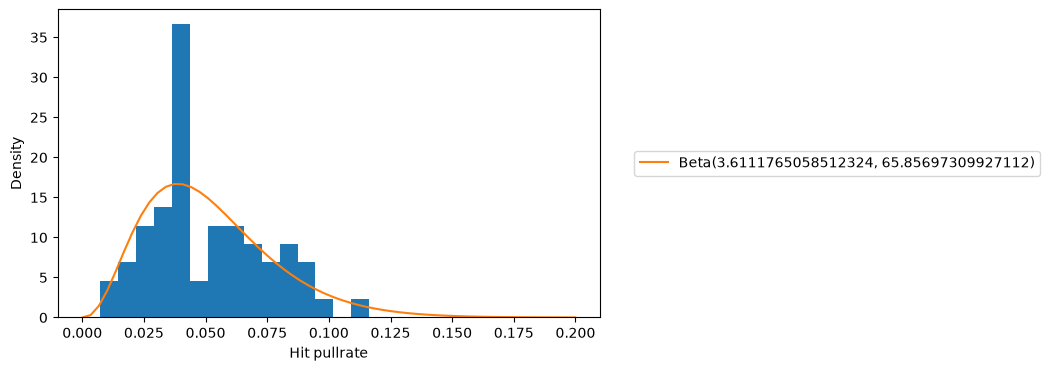

In [38]:
x2 = np.linspace(0, 0.2, 60)
plt.hist(sets.beta_pullrate, bins = 15, density = True)
plt.plot(x2, stats.beta(alpha_pull, beta_pull).pdf(x2), label = f"Beta({alpha_pull}, {beta_pull})")
plt.xlabel('Hit pullrate')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()

In [39]:
sets['eb_estimate'] = ((sets.hits+ alpha_pull) / (sets.packs + alpha_pull + beta_pull))

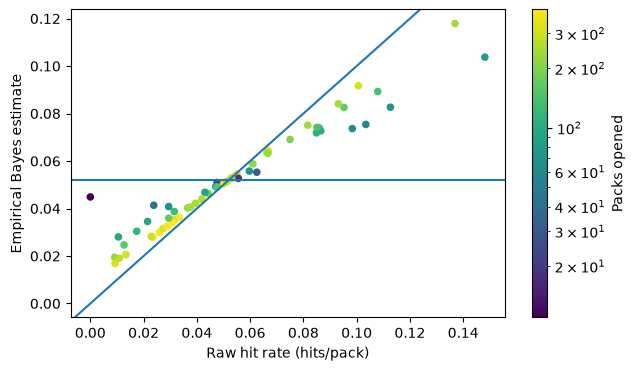

In [40]:
sc = plt.scatter(sets.sim_rate, sets.eb_estimate, c=sets.packs, norm=colors.LogNorm(), cmap="viridis", s=20)
plt.axline((0, 0), slope=1)
plt.axhline(alpha_pull / (alpha_pull + beta_pull))
plt.colorbar(sc, label="Packs opened")
plt.xlabel('Raw hit rate (hits/pack)')
plt.ylabel('Empirical Bayes estimate')
plt.show()

Once again, sets with fewer packs opened shrink more.

## References

- *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapter 3.
- Lahman Baseball Database (CC BY-SA 3.0): https://sabr.org/lahman-database/
- SciPy `betabinom`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.betabinom.html
- Efron, *Large-Scale Inference* (2010), Chapter 1, for the empirical Bayes idea in general.